# Aula 01 Hands-On — Perceptron, Regressão Logística e XOR

## Contexto
Nesta prática, vamos testar o limite geométrico dos modelos lineares antes de avançar para arquiteturas profundas. O notebook foi desenhado para responder a uma pergunta simples, mas estrutural para todo o curso: quando um neurônio linear é suficiente e quando a não linearidade deixa de ser opcional?

## Objetivos de aprendizagem
- Comparar um baseline ingênuo, o perceptron, a regressão logística e um MLP mínimo em dois cenários controlados.
- Medir desempenho com métricas coerentes com classificação binária e interpretar o que cada métrica captura.
- Visualizar fronteiras de decisão para distinguir erro de treinamento de limitação de representabilidade.
- Consolidar a intuição de por que XOR exige uma transformação não linear do espaço de atributos.

## Pergunta experimental e hipótese
**Pergunta:** um classificador linear treinado corretamente consegue resolver qualquer problema binário simples em 2D?

**Hipótese:**
- Em dados linearmente separáveis, perceptron e regressão logística devem atingir desempenho alto e fronteira estável.
- Em XOR, a regressão logística deve continuar limitada por uma fronteira linear, enquanto um MLP raso com ativação não linear deve capturar a estrutura correta.
- O ganho do MLP deve aparecer não apenas na acurácia, mas também na redução de erros concentrados nas regiões ambíguas do plano.

## Setup, imports e semente de reprodutibilidade
Antes de gerar os dados, fixamos a semente e concentramos os imports. Isso garante que as mesmas amostras sintéticas, partições e inicializações sejam reproduzíveis quando o notebook for reexecutado em outra máquina ou em outro semestre da disciplina.

In [1]:
import random
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

## Geração dos datasets
Usaremos dois cenários complementares. O primeiro é linearmente separável e serve para verificar se a hipótese do perceptron é verdadeira quando suas premissas são respeitadas. O segundo é um XOR com ruído leve, construído exatamente para falsificar essa hipótese e mostrar que o problema não está na otimização, e sim na família de funções.

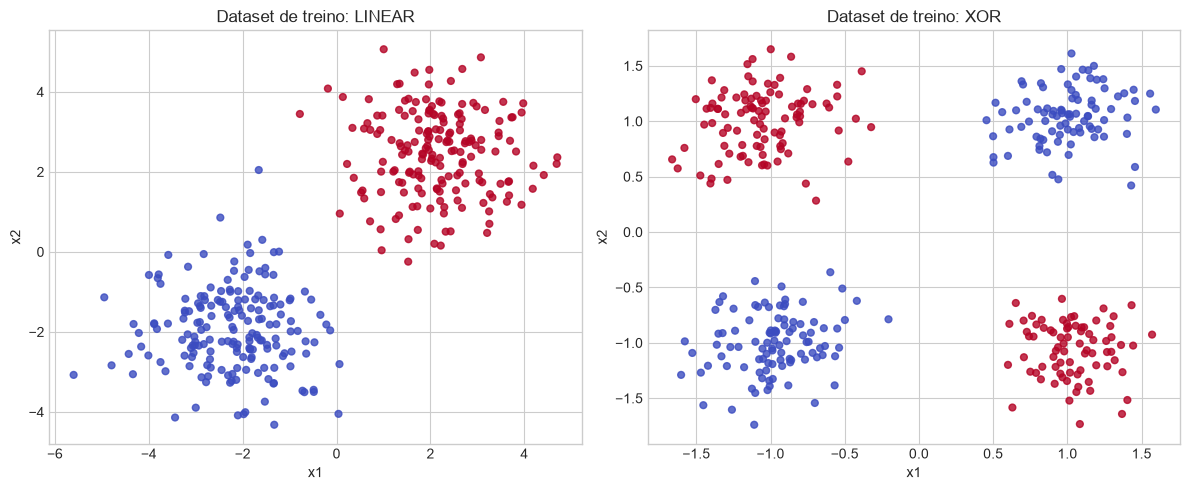

In [2]:
def make_xor(n_samples=600, noise=0.25, seed=SEED):
    rng = np.random.default_rng(seed)
    quadrants = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]], dtype=float)
    labels = np.array([0, 1, 1, 0])
    choices = rng.integers(0, len(quadrants), size=n_samples)
    X = quadrants[choices] + rng.normal(scale=noise, size=(n_samples, 2))
    y = labels[choices]
    return X, y

def split_three_ways(X, y, seed=SEED):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, stratify=y, random_state=seed
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed
    )
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test),
    }

X_linear, y_linear = make_blobs(
    n_samples=600,
    centers=[(-2.2, -2.0), (2.0, 2.3)],
    cluster_std=1.05,
    random_state=SEED,
)
X_xor, y_xor = make_xor()

datasets = {
    'linear': split_three_ways(X_linear, y_linear),
    'xor': split_three_ways(X_xor, y_xor),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, split) in zip(axes, datasets.items()):
    X_train, y_train = split['train']
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.8)
    ax.set_title(f'Dataset de treino: {name.upper()}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
plt.tight_layout()

## Baselines e por que eles importam
O baseline majoritário mede o ganho mínimo de um modelo que ignora completamente a geometria dos dados. O perceptron explicita o caso clássico de separação linear com função degrau. A regressão logística mantém a hipótese linear, mas adiciona probabilidades calibráveis. Se o MLP superar a regressão logística apenas em XOR, teremos uma evidência limpa de que a não linearidade foi o fator decisivo.

In [3]:
def build_models():
    return {
        'majoritario': DummyClassifier(strategy='most_frequent'),
        'perceptron': Pipeline([
            ('scaler', StandardScaler()),
            ('model', Perceptron(random_state=SEED, max_iter=1000, tol=1e-4)),
        ]),
        'logistica': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, random_state=SEED)),
        ]),
    }

baseline_models = build_models()
baseline_models.keys()

dict_keys(['majoritario', 'perceptron', 'logistica'])

## Método principal
Nosso método principal será um MLP mínimo com uma camada oculta ReLU. A escolha é deliberadamente conservadora: queremos a menor mudança arquitetural possível para testar a hipótese de que uma única não linearidade já altera a classe de funções de forma suficiente para resolver XOR. Também vamos criar uma função de visualização da fronteira de decisão para ligar métrica e geometria.

In [4]:
def build_mlp():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(8,),
            activation='relu',
            solver='adam',
            learning_rate_init=0.02,
            alpha=1e-4,
            max_iter=1500,
            random_state=SEED,
        )),
    ])

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if hasattr(model, 'predict_proba'):
        zz = model.predict_proba(grid)[:, 1]
    else:
        decision = model.decision_function(grid)
        zz = 1 / (1 + np.exp(-decision))

    zz = zz.reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.25)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=24, edgecolor='k', linewidth=0.2)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

## Métricas e interpretação
Usaremos `accuracy` e `balanced accuracy` para capturar acerto global e robustez ao balanceamento. `F1` resume o compromisso entre precisão e recall. Quando o modelo fornece probabilidades, adicionamos `log loss` e `ROC-AUC`, porque um modelo pode acertar a classe final e ainda assim estar mal calibrado ou excessivamente confiante.

In [5]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    metrics = {
        'accuracy': accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1': f1_score(y, preds),
    }

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)[:, 1]
        metrics['log_loss'] = log_loss(y, np.column_stack([1 - probs, probs]))
        metrics['roc_auc'] = roc_auc_score(y, probs)
    return metrics

## Execução do treinamento e da avaliação
Agora executamos o protocolo completo: cada modelo é treinado no conjunto de treino, selecionado com base no desempenho de validação e reportado no conjunto de teste. A tabela abaixo consolida as métricas de validação e teste dos oito modelos (dois cenários × quatro modelos); logo abaixo dela, inspecionamos explicitamente as fronteiras em XOR para verificar se o ganho do MLP decorre de uma mudança geométrica coerente com a hipótese inicial.

,dataset,modelo,val_accuracy,test_accuracy,test_balanced_accuracy,test_f1,test_log_loss,test_roc_auc
1,linear,perceptron,0.991667,1.000000,1.000000,1.000000,NaN,NaN
2,linear,logistica,0.991667,1.000000,1.000000,1.000000,0.019172,1.000000
3,linear,mlp_raso,0.991667,1.000000,1.000000,1.000000,0.002331,1.000000
0,linear,majoritario,0.500000,0.500000,0.500000,0.000000,18.021827,0.500000
7,xor,mlp_raso,1.000000,1.000000,1.000000,1.000000,0.007084,1.000000
6,xor,logistica,0.633333,0.725000,0.719410,0.659794,0.692429,0.551724
5,xor,perceptron,0.750000,0.700000,0.709677,0.763158,NaN,NaN
4,xor,majoritario,0.508333,0.516667,0.500000,0.000000,17.421099,0.500000


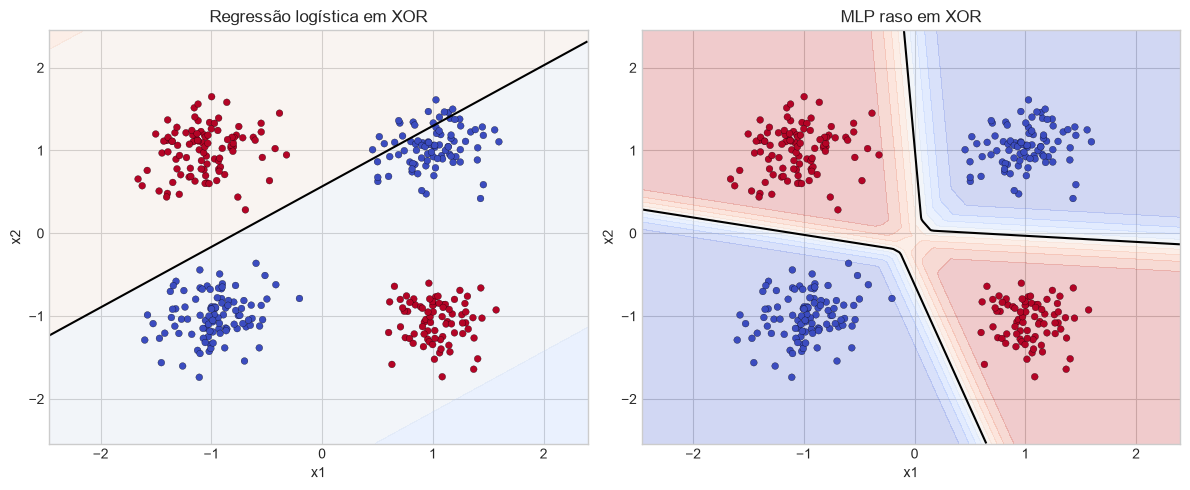

In [6]:
results = []
fitted_models = {}

for dataset_name, split in datasets.items():
    X_train, y_train = split['train']
    X_val, y_val = split['val']
    X_test, y_test = split['test']

    model_builders = build_models()
    model_builders['mlp_raso'] = build_mlp()

    for model_name, model in model_builders.items():
        model.fit(X_train, y_train)
        val_metrics = evaluate_model(model, X_val, y_val)
        test_metrics = evaluate_model(model, X_test, y_test)

        results.append({
            'dataset': dataset_name,
            'modelo': model_name,
            'val_accuracy': val_metrics['accuracy'],
            'test_accuracy': test_metrics['accuracy'],
            'test_balanced_accuracy': test_metrics['balanced_accuracy'],
            'test_f1': test_metrics['f1'],
            'test_log_loss': test_metrics.get('log_loss', np.nan),
            'test_roc_auc': test_metrics.get('roc_auc', np.nan),
        })
        fitted_models[(dataset_name, model_name)] = deepcopy(model)

results_df = pd.DataFrame(results).sort_values(['dataset', 'test_accuracy'], ascending=[True, False])
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
xor_split = datasets['xor']
X_xor_train, y_xor_train = xor_split['train']
plot_boundary(axes[0], fitted_models[('xor', 'logistica')], X_xor_train, y_xor_train, 'Regressão logística em XOR')
plot_boundary(axes[1], fitted_models[('xor', 'mlp_raso')], X_xor_train, y_xor_train, 'MLP raso em XOR')
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
Se a regressão logística concentrar erros nos quadrantes cruzados de XOR, a leitura correta não é que faltou ajuste fino, mas que a hipótese linear falhou. O próximo experimento natural é aumentar a largura do MLP, variar a ativação e medir se o ganho adicional vem de mais capacidade ou apenas de maior estabilidade numérica. Também vale testar ruído mais alto para observar como a margem geométrica se degrada. Abaixo, além do mapa de erros no teste, a tabela do cenário XOR é exibida junto com a matriz de confusão do perceptron, que explica por que o F1 dele supera o da regressão logística mesmo com acurácia menor.

,modelo,test_accuracy,test_f1,test_log_loss,test_roc_auc
7,mlp_raso,1.000000,1.000000,0.007084,1.000000
6,logistica,0.725000,0.659794,0.692429,0.551724
5,perceptron,0.700000,0.763158,NaN,NaN
4,majoritario,0.516667,0.000000,17.421099,0.500000


Matriz de confusão do perceptron em XOR (teste) — linhas: classe real 0/1; colunas: classe prevista 0/1
[[26 36]
 [ 0 58]]


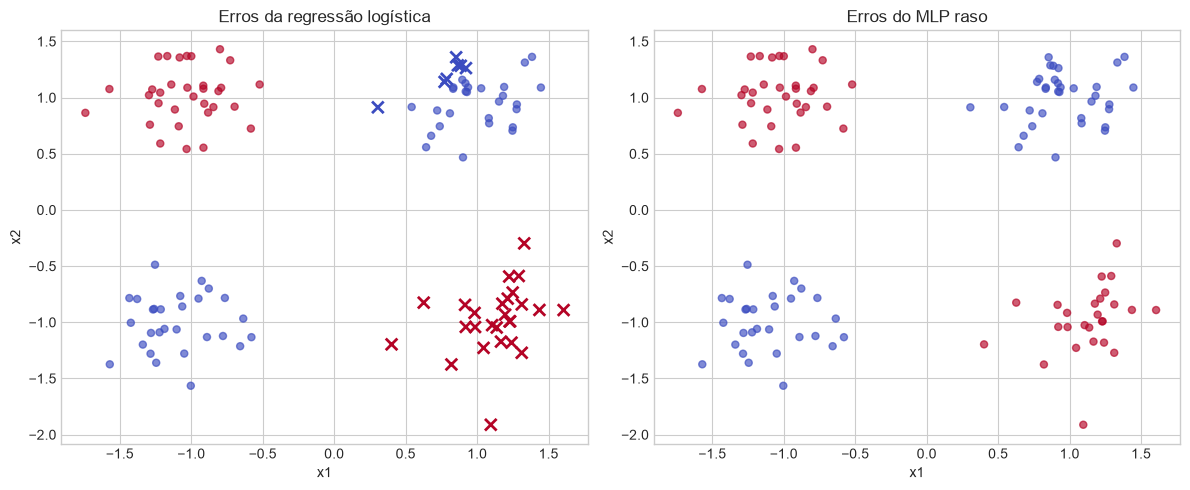

In [7]:
X_test, y_test = datasets['xor']['test']
logistic_preds = fitted_models[('xor', 'logistica')].predict(X_test)
mlp_preds = fitted_models[('xor', 'mlp_raso')].predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in [
    (axes[0], logistic_preds, 'Erros da regressão logística'),
    (axes[1], mlp_preds, 'Erros do MLP raso'),
]:
    correct = preds == y_test
    ax.scatter(X_test[correct, 0], X_test[correct, 1], c=y_test[correct], cmap='coolwarm', s=26, alpha=0.65)
    ax.scatter(X_test[~correct, 0], X_test[~correct, 1], c=y_test[~correct], cmap='coolwarm', s=70, marker='x', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
plt.tight_layout()

display(results_df.query("dataset == 'xor'")[['modelo', 'test_accuracy', 'test_f1', 'test_log_loss', 'test_roc_auc']])

perceptron_preds = fitted_models[('xor', 'perceptron')].predict(X_test)
print('Matriz de confusão do perceptron em XOR (teste) — linhas: classe real 0/1; colunas: classe prevista 0/1')
print(confusion_matrix(y_test, perceptron_preds))

## Fechamento e próximos passos
O experimento deve mostrar que o perceptron e a regressão logística são excelentes quando a fronteira verdadeira é aproximadamente linear, mas esbarram em uma limitação estrutural em XOR. O MLP raso introduz a menor não linearidade útil e já altera o espaço de decisão o bastante para resolver o problema. Na próxima aula, vamos transformar essa intuição em aprendizado paramétrico via backpropagation, acompanhando gradientes, loss e generalização em um problema multiclasse real.